# Imports

In [38]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../utils')
from myutils import display_report, plot_categorical_dual, plot_numeric_report

print("Libraries loaded.")

Библиотеки загружены.


# 2. Loading data

In [39]:
RAW_PATH   = "../data/raw/Calls (Done).xlsx"
CLEAN_PATH = "../data/clean/calls_clean.pkl"

df = pd.read_excel(
    RAW_PATH,
    dtype={"Id": str})

print(f"Size: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Task was destroyed but it is pending!
task: <Task pending name='Task-276' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-277' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-277' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-460' coro=<_async_in_context.<locals>.run_in_context() done, defin

Размер: (95874, 9)
Столбцы: ['Id', 'Call Start Time', 'Call Owner Name', 'CONTACTID', 'Call Type', 'Call Duration (in seconds)', 'Call Status', 'Outgoing Call Status', 'Scheduled in CRM']


,Id,Call Start Time,Call Owner Name,CONTACTID,Call Type,Call Duration (in seconds),Call Status,Outgoing Call Status,Scheduled in CRM
0,5805028000000805001,30.06.2023 08:43,John Doe,NaN,Inbound,171.0,Received,NaN,NaN
1,5805028000000768006,30.06.2023 08:46,John Doe,NaN,Outbound,28.0,Attended Dialled,Completed,0.0
2,5805028000000764027,30.06.2023 08:59,John Doe,NaN,Outbound,24.0,Attended Dialled,Completed,0.0


# 3. Initial overview

In [40]:
display_report(df, df_name="Calls (raw)")

  ОТЧЁТ: Calls (raw)
  Размер : 95,874 строк × 9 столбцов
  Память : 13.73 MB

  Пропуски (NaN):
    CONTACTID                                  3933 (4.1%)
    Call Duration (in seconds)                   83 (0.1%)
    Outgoing Call Status                       8999 (9.4%)
    Scheduled in CRM                           8999 (9.4%)

  КАТЕГОРИАЛЬНЫЕ столбцы:
              column dtype  n_unique           top_value  top_freq  top_pct  null_count  null_pct
                  Id   str     95874 5805028000000805001         1     0.00           0      0.00
     Call Start Time   str     68445    06.06.2024 15:07         9     0.01           0      0.00
     Call Owner Name   str        33        Yara Edwards      9059     9.45           0      0.00
           Call Type   str         3            Outbound     86875    90.61           0      0.00
         Call Status   str        11    Attended Dialled     70703    73.75           0      0.00
Outgoing Call Status   str         4           Compl

# 4. Date conversion and feature creation

In [41]:
df["Call Start Time"] = pd.to_datetime(df["Call Start Time"], errors="coerce")

# Extract date, hour, and day of week — useful for activity analysis
df["call_date"] = df["Call Start Time"].dt.normalize()
df["call_hour"] = df["Call Start Time"].dt.hour
df["day_of_week"] = df["Call Start Time"].dt.day_name()

print("Date-based features created.")
df[["Call Start Time", "call_date", "call_hour", "day_of_week"]]

Признаки из даты созданы.


,Call Start Time,call_date,call_hour,day_of_week
0,2023-06-30 08:43:00,2023-06-30,8,Friday
1,2023-06-30 08:46:00,2023-06-30,8,Friday
2,2023-06-30 08:59:00,2023-06-30,8,Friday
3,2023-06-30 09:20:00,2023-06-30,9,Friday
4,2023-06-30 09:30:00,2023-06-30,9,Friday
...,...,...,...,...
95869,2024-06-21 15:30:00,2024-06-21,15,Friday
95870,2024-06-21 15:30:00,2024-06-21,15,Friday
95871,2024-06-21 15:30:00,2024-06-21,15,Friday
95872,2024-06-21 15:30:00,2024-06-21,15,Friday


# 5. Call duration validation

In [42]:
# Negative values indicate data errors and are replaced with 0

print("Call duration statistics (before cleaning):")
df["Call Duration (in seconds)"].describe()

Статистика длительности (до очистки):


count    95791.000000
mean       164.977263
std        401.410826
min          0.000000
25%          4.000000
50%          8.000000
75%         98.000000
max       7625.000000
Name: Call Duration (in seconds), dtype: float64

In [43]:
# Negative values -> 0
neg = (df["Call Duration (in seconds)"] < 0).sum()
print(f"\nNegative values: {neg}")
df.loc[df["Call Duration (in seconds)"] < 0, "Call Duration (in seconds)"] = 0

# Fill missing values with zero and convert to integer type
df["Call Duration (in seconds)"] = df["Call Duration (in seconds)"].fillna(0).astype("int64")

# Add call duration in minutes for convenience
df["duration_min"] = (df["Call Duration (in seconds)"] / 60).round(2)

print("\nStatistics after cleaning:")
df["Call Duration (in seconds)"].describe()


Отрицательных значений: 0

Статистика после очистки:


count    95874.000000
mean       164.834439
std        401.266369
min          0.000000
25%          4.000000
50%          8.000000
75%         97.000000
max       7625.000000
Name: Call Duration (in seconds), dtype: float64

# 6. Missing values handling

In [44]:
print("Missing values before cleaning:")
print(df.isna().sum()[df.isna().sum() > 0])

Пропуски до очистки:
CONTACTID               3933
Outgoing Call Status    8999
Scheduled in CRM        8999
dtype: int64


In [45]:
print(df["Call Owner Name"].isna().sum())

0


In [46]:
df["Call Owner Name"]

0             John Doe
1             John Doe
2             John Doe
3             John Doe
4             John Doe
             ...      
95869    Ulysses Adams
95870    Victor Barnes
95871     Kevin Parker
95872    Victor Barnes
95873         John Doe
Name: Call Owner Name, Length: 95874, dtype: str

In [47]:
df = df.dropna(subset=["Call Owner Name"]).reset_index(drop=True)
df

,Id,Call Start Time,Call Owner Name,CONTACTID,Call Type,Call Duration (in seconds),Call Status,Outgoing Call Status,Scheduled in CRM,call_date,call_hour,day_of_week,duration_min
0,5805028000000805001,2023-06-30 08:43:00,John Doe,NaN,Inbound,171,Received,NaN,NaN,2023-06-30,8,Friday,2.85
1,5805028000000768006,2023-06-30 08:46:00,John Doe,NaN,Outbound,28,Attended Dialled,Completed,0.0,2023-06-30,8,Friday,0.47
2,5805028000000764027,2023-06-30 08:59:00,John Doe,NaN,Outbound,24,Attended Dialled,Completed,0.0,2023-06-30,8,Friday,0.40
3,5805028000000787003,2023-06-30 09:20:00,John Doe,5.805028e+18,Outbound,6,Attended Dialled,Completed,0.0,2023-06-30,9,Friday,0.10
4,5805028000000768019,2023-06-30 09:30:00,John Doe,5.805028e+18,Outbound,11,Attended Dialled,Completed,0.0,2023-06-30,9,Friday,0.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95869,5805028000056889515,2024-06-21 15:30:00,Ulysses Adams,5.805028e+18,Outbound,6,Attended Dialled,Completed,0.0,2024-06-21,15,Friday,0.10
95870,5805028000056875317,2024-06-21 15:30:00,Victor Barnes,5.805028e+18,Outbound,8,Attended Dialled,Completed,0.0,2024-06-21,15,Friday,0.13
95871,5805028000056832495,2024-06-21 15:30:00,Kevin Parker,5.805028e+18,Outbound,5,Attended Dialled,Completed,0.0,2024-06-21,15,Friday,0.08
95872,5805028000056893619,2024-06-21 15:30:00,Victor Barnes,5.805028e+18,Outbound,0,Unattended Dialled,Completed,0.0,2024-06-21,15,Friday,0.00


In [48]:
# Contact_id can be missing (call without an associated contact), replace with "No Contact"
df["CONTACTID"] = df["CONTACTID"].fillna("No Contact")

# If call status is missing, set to "Not Available" — status is unknown, do not create assumptions
df["Outgoing Call Status"] = df["Outgoing Call Status"].fillna("Not Available")

# If there is no scheduling information in CRM, assume the call was not scheduled (False)
df["Scheduled in CRM"] = df["Scheduled in CRM"].fillna(False)

print("\nMissing values after cleaning:")
remaining = df.isna().sum()
print(remaining[remaining > 0] if remaining.any() else "No critical missing values.")


Пропуски после очистки:
Критических пропусков нет.


# 7. Removing duplicates

In [49]:
dups = df.duplicated(subset=["Id"]).sum()
print(f"Duplicate IDs: {dups}")

Дублирующихся id: 0


In [50]:
df = df.drop_duplicates(subset=["Id"]).reset_index(drop=True)
print(f"Dataset size after removing duplicates: {df.shape}")

Размер после удаления дубликатов: (95874, 13)


# 8. Data type optimization

In [51]:
df["Id"] = df["Id"].astype("string")
df["CONTACTID"] = df["CONTACTID"].astype("string")
df["Call Owner Name"] = df["Call Owner Name"].astype("category")
df["Call Type"] = df["Call Type"].astype("category")
df["Call Status"] = df["Call Status"].astype("category")
df["Outgoing Call Status"]= df["Outgoing Call Status"].astype("category")
df["day_of_week"] = df["day_of_week"].astype("category")
df["Scheduled in CRM"] = df["Scheduled in CRM"].astype(bool)

print("Data types have been set.")
df.dtypes

Типы данных установлены.


Id                                    string
Call Start Time               datetime64[us]
Call Owner Name                     category
CONTACTID                             string
Call Type                           category
Call Duration (in seconds)             int64
Call Status                         category
Outgoing Call Status                category
Scheduled in CRM                        bool
call_date                     datetime64[us]
call_hour                              int32
day_of_week                         category
duration_min                         float64
dtype: object

# 9. Feature: whether the call was answered

In [52]:
# List of statuses where the call is considered successfully connected
connected = df["Call Status"].value_counts()
print("All call statuses:")
print(connected)

Все статусы звонков:
Call Status
Attended Dialled              70703
Unattended Dialled            16030
Missed                         5922
Received                       3077
Overdue                          60
Scheduled Attended Delay         22
Cancelled                        20
Scheduled Unattended Delay       17
Scheduled Attended               14
Scheduled Unattended              6
Scheduled                         3
Name: count, dtype: int64


In [53]:
connected_statuses = {"Attended Dialled", "Received", "Scheduled Attended", "Scheduled Attended Delay"}

df["is_connected"] = df["Call Status"].isin(connected_statuses)

print(f"\nConnected calls: {df['is_connected'].sum():,} "
      f"({df['is_connected'].mean()*100:.1f}%)")


Принятых звонков: 73,816 (77.0%)


In [54]:
not_connected_statuses = {"Missed", "Unattended Dialled", "Cancelled", "Scheduled Unattended"}

df["is_not_connected"] = df["Call Status"].isin(not_connected_statuses)

print(f"\nNot connected calls: {df['is_not_connected'].sum():,} "
      f"({df['is_not_connected'].mean()*100:.1f}%)")


Непринятых звонков: 21,978 (22.9%)


# 10. Final report

In [55]:
df

,Id,Call Start Time,Call Owner Name,CONTACTID,Call Type,Call Duration (in seconds),Call Status,Outgoing Call Status,Scheduled in CRM,call_date,call_hour,day_of_week,duration_min,is_connected,is_not_connected
0,5805028000000805001,2023-06-30 08:43:00,John Doe,No Contact,Inbound,171,Received,Not Available,False,2023-06-30,8,Friday,2.85,True,False
1,5805028000000768006,2023-06-30 08:46:00,John Doe,No Contact,Outbound,28,Attended Dialled,Completed,False,2023-06-30,8,Friday,0.47,True,False
2,5805028000000764027,2023-06-30 08:59:00,John Doe,No Contact,Outbound,24,Attended Dialled,Completed,False,2023-06-30,8,Friday,0.40,True,False
3,5805028000000787003,2023-06-30 09:20:00,John Doe,5.805028000000645e+18,Outbound,6,Attended Dialled,Completed,False,2023-06-30,9,Friday,0.10,True,False
4,5805028000000768019,2023-06-30 09:30:00,John Doe,5.805028000000645e+18,Outbound,11,Attended Dialled,Completed,False,2023-06-30,9,Friday,0.18,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95869,5805028000056889515,2024-06-21 15:30:00,Ulysses Adams,5.805028000056564e+18,Outbound,6,Attended Dialled,Completed,False,2024-06-21,15,Friday,0.10,True,False
95870,5805028000056875317,2024-06-21 15:30:00,Victor Barnes,5.805028000054867e+18,Outbound,8,Attended Dialled,Completed,False,2024-06-21,15,Friday,0.13,True,False
95871,5805028000056832495,2024-06-21 15:30:00,Kevin Parker,5.805028000010618e+18,Outbound,5,Attended Dialled,Completed,False,2024-06-21,15,Friday,0.08,True,False
95872,5805028000056893619,2024-06-21 15:30:00,Victor Barnes,5.805028000056839e+18,Outbound,0,Unattended Dialled,Completed,False,2024-06-21,15,Friday,0.00,False,True


In [56]:
display_report(df, df_name="Calls (clean)")

  ОТЧЁТ: Calls (clean)
  Размер : 95,874 строк × 15 столбцов
  Память : 9.09 MB

  Пропусков нет.

  КАТЕГОРИАЛЬНЫЕ столбцы:
              column    dtype  n_unique        top_value  top_freq  top_pct  null_count  null_pct
     Call Owner Name category        33     Yara Edwards      9059     9.45           0       0.0
           Call Type category         3         Outbound     86875    90.61           0       0.0
         Call Status category        11 Attended Dialled     70703    73.75           0       0.0
Outgoing Call Status category         5        Completed     86792    90.53           0       0.0
         day_of_week category         7        Wednesday     17721    18.48           0       0.0

  ЧИСЛОВЫЕ столбцы:
                    column  count   mean  median  mode    std  min     max   range  null_count  null_pct
Call Duration (in seconds)  95874 164.83    8.00   0.0 401.27  0.0 7625.00 7625.00           0       0.0
                 call_hour  95874  14.35   14.00  17.0  

# 11. Visualizations

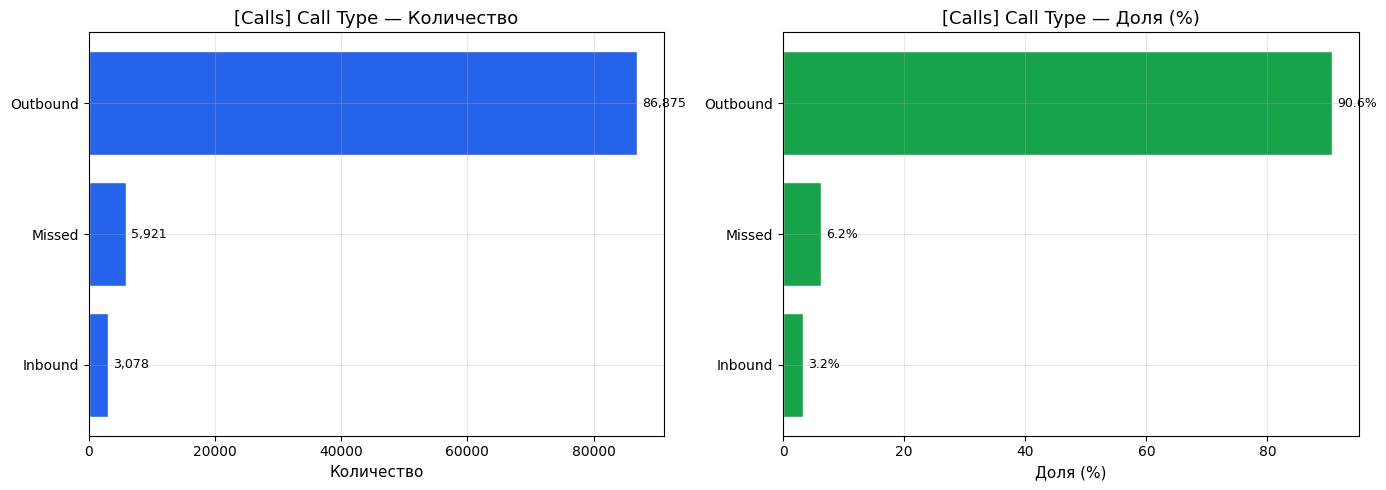

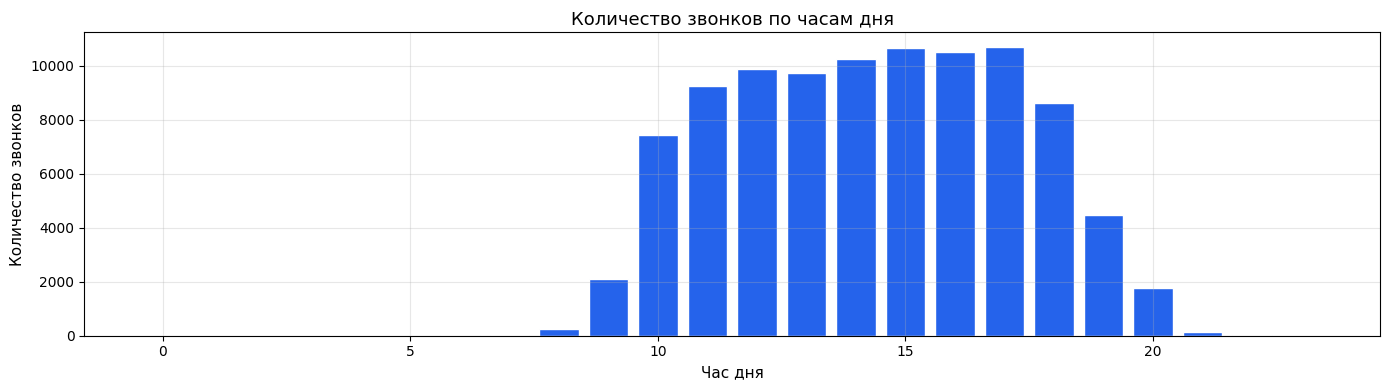

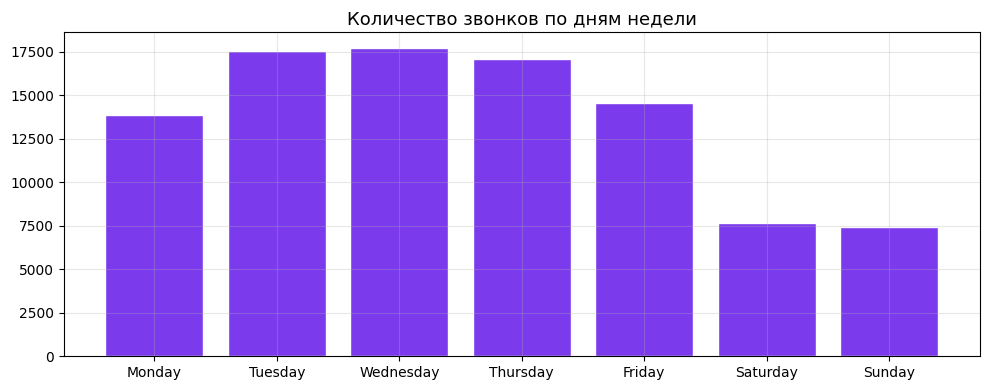

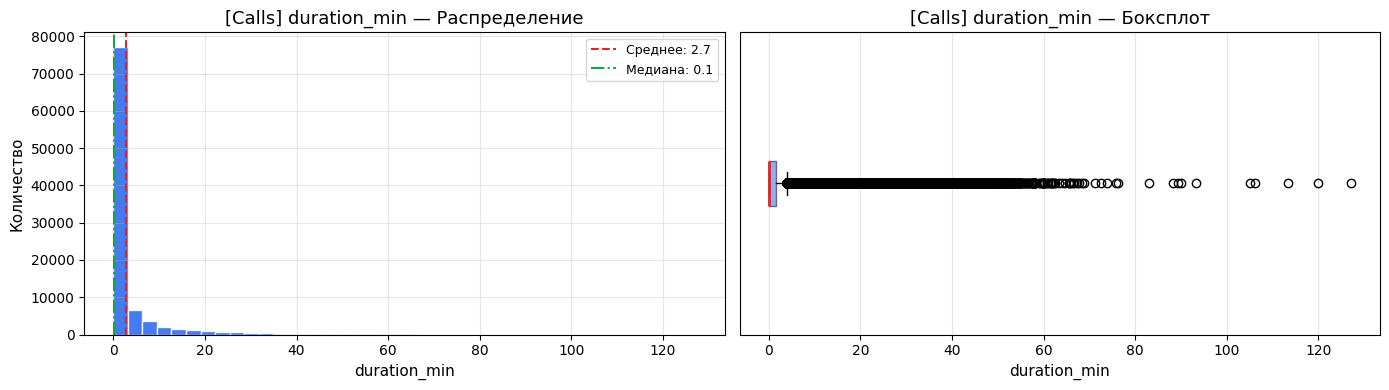

In [57]:
# 1. Call types
plot_categorical_dual(
    df["Call Type"], col_name="Call Type",
    df_name="Calls", top_n=5
)

# 2. Calls by hour of the day
hour_counts = df["call_hour"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(hour_counts.index, hour_counts.values,
       color="#2563EB", edgecolor="white")
ax.set_title("Number of calls by hour of the day", fontsize=13)
ax.set_xlabel("Hour of the day")
ax.set_ylabel("Number of calls")
plt.tight_layout()
plt.show()

# 3. Calls by day of the week
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_counts = df["day_of_week"].value_counts().reindex(day_order, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(day_counts.index, day_counts.values,
       color="#7C3AED", edgecolor="white")
ax.set_title("Number of calls by day of the week", fontsize=13)
plt.tight_layout()
plt.show()

# 4. Call duration distribution
plot_numeric_report(df[["duration_min"]], df_name="Calls")

# 12. Key insights

In [58]:
total = len(df)
inbound = (df["Call Type"] == "Inbound").sum()
missed = (df["Call Type"] == "Missed").sum()
outbound = (df["Call Type"] == "Outbound").sum()

print(f"Total calls     : {total:,}")
print(f"Inbound calls   : {inbound:,}  ({inbound/total*100:.1f}%)")
print(f"Missed calls    : {missed:,}   ({missed/total*100:.1f}%)")
print(f"Outbound calls  : {outbound:,} ({outbound/total*100:.1f}%)")

Всего звонков  : 95,874
Входящие       : 3,078  (3.2%)
Пропущенные    : 5,921   (6.2%)
Исходящие      : 86,875 (90.6%)


# 13. Saving

In [59]:
df.to_pickle(CLEAN_PATH)
print(f"Saved: {CLEAN_PATH}")
print(f"Size: {df.shape}")
df.info()

Сохранено: ../data/clean/calls_clean.pkl
Размер: (95874, 15)
<class 'pandas.DataFrame'>
RangeIndex: 95874 entries, 0 to 95873
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Id                          95874 non-null  string        
 1   Call Start Time             95874 non-null  datetime64[us]
 2   Call Owner Name             95874 non-null  category      
 3   CONTACTID                   95874 non-null  string        
 4   Call Type                   95874 non-null  category      
 5   Call Duration (in seconds)  95874 non-null  int64         
 6   Call Status                 95874 non-null  category      
 7   Outgoing Call Status        95874 non-null  category      
 8   Scheduled in CRM            95874 non-null  bool          
 9   call_date                   95874 non-null  datetime64[us]
 10  call_hour                   95874 non-null  int32         
 11  day_